# Tugas 1 - Klasifikasi Wine Quality dengan KNN
  
| Nama              | NRP        |
|-------------------|------------|
|      Muhammad Fasya Atthaya Rosyada        |   5054251006    |

## Deskripsi Tugas
Pada tugas ini, kita akan menggunakan Wine Quality Dataset. Dataset bisa diakses melalui link berikut:\
🔗 https://www.kaggle.com/datasets/yasserh/wine-quality-dataset

Tujuan utama dari tugas ini adalah membangun model K-Nearest Neighbors (KNN) untuk mengklasifikasikan kualitas wine. 

Langkah-langkah yang harus dilakukan antara lain:
1. Persiapan Dataset & Eksplorasi Awal

- Memuat dataset, melihat struktur data, dan distribusi label.

2. Preprocessing 
- Memproses data agar siap untuk digunakan dalam membangun model.

3. Eksperimen Model KNN
- Bangun model KNN dengan mencoba beberapa nilai k (misalnya 3, 5, dan 7 --> BEBAS) serta dua metric jarak (seperti Euclidean dan Manhattan).
- Eksperimen ini bertujuan untuk membandingkan performa KNN dengan parameter yang berbeda.

4. Evaluasi Model
- Hitung metrik evaluasi seperti Accuracy, Precision, Recall, F1-Score, serta visualisasikan Confusion Matrix.

5. Analisis & Kesimpulan
- Bandingkan hasil antar eksperimen yang telah dilakukan dan berikan kesimpulan.


# 1. Persiapan Dataset & Eksplorasi Awal

In [1]:
# Import library yang dibutuhkan (pandas, numpy, matplotlib, dll) 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

sns.set_theme(style="whitegrid")

In [2]:
#  Load Dataset dan menampilkan informasi dasar tentang dataset, seperti jumlah baris dan kolom, tipe data, jumlah nilai yang hilang, dan informasi lainnya yang dibutuhkan.
data = pd.read_csv('WineQT.csv')
if 'Id' in data.columns:
    data.drop('Id', axis=1, inplace=True)

print("--- 5 Baris Pertama Data ---")
display(data.head())

print("\n--- Informasi Dataset ---")
data.info()

print("\n--- Statistik Deskriptif ---")
display(data.describe())

--- 5 Baris Pertama Data ---


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5



--- Informasi Dataset ---
<class 'pandas.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 107.3 KB

--- Statistik Deskriptif ---


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000
mean,8.311111,0.531339,0.268364,2.532152,0.086933,15.615486,45.914698,0.996730,3.311015,0.657708,10.442111,5.657043
std,1.747595,0.179633,0.196686,1.355917,0.047267,10.250486,32.782130,0.001925,0.156664,0.170399,1.082196,0.805824
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.392500,0.090000,1.900000,0.070000,7.000000,21.000000,0.995570,3.205000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.250000,2.200000,0.079000,13.000000,37.000000,0.996680,3.310000,0.620000,10.200000,6.000000
75%,9.100000,0.640000,0.420000,2.600000,0.090000,21.000000,61.000000,0.997845,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,68.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


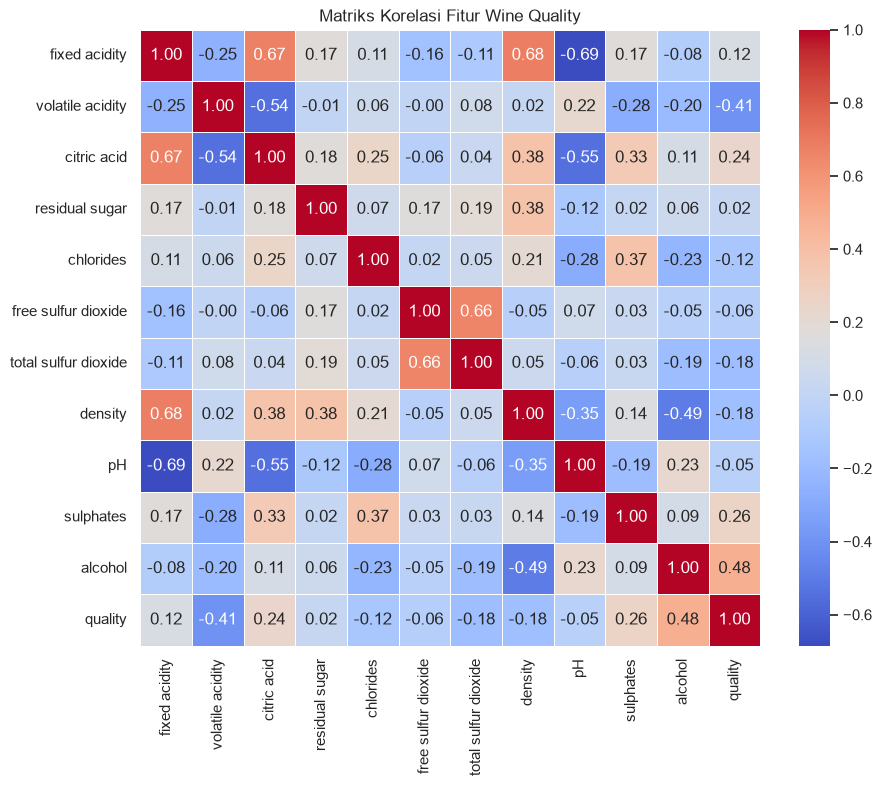

In [3]:
# Tampilkan Korelasi Matrix
plt.figure(figsize=(10, 8))
correlation_matrix = data.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Matriks Korelasi Fitur Wine Quality')
plt.show()

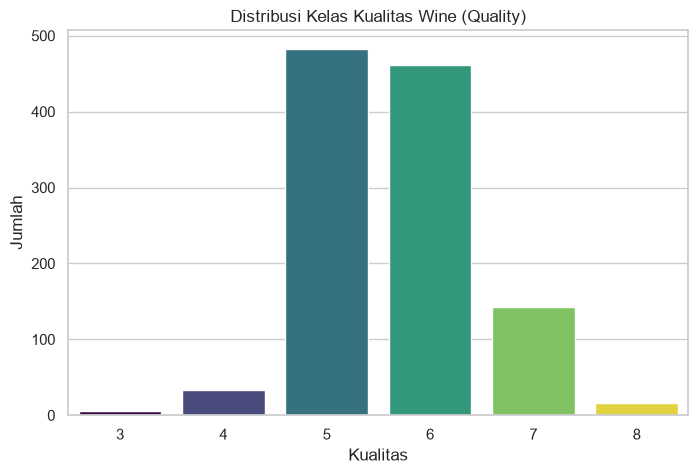

In [4]:
# Tampilkan distribusi label (quality) dalam bentuk visualisasi, misalnya menggunakan histogram atau bar plot.
plt.figure(figsize=(8, 5))
sns.countplot(x='quality', data=data, hue='quality', palette='viridis', legend=False)
plt.title('Distribusi Kelas Kualitas Wine (Quality)')
plt.xlabel('Kualitas')
plt.ylabel('Jumlah')
plt.show()

## Silahkan Lakukan Exploratory Data Analysis (EDA) tambahan yang dibutuhkan. 

# 2. Preprocessing




In [5]:
# NaN handling (drop, impute, etc.), duplicate handling, dan lain-lain.
print("--- Missing Values per Kolom ---")
display(data.isnull().sum().to_frame(name='Jumlah NaN'))

print(f"\nJumlah baris duplikat awal: {data.duplicated().sum()}")

data.drop_duplicates(inplace=True)
print(f"Baris duplikat setelah dihapus: {data.duplicated().sum()}")

--- Missing Values per Kolom ---


,Jumlah NaN
fixed acidity,0
volatile acidity,0
citric acid,0
residual sugar,0
chlorides,0
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,0
sulphates,0



Jumlah baris duplikat awal: 125
Baris duplikat setelah dihapus: 0


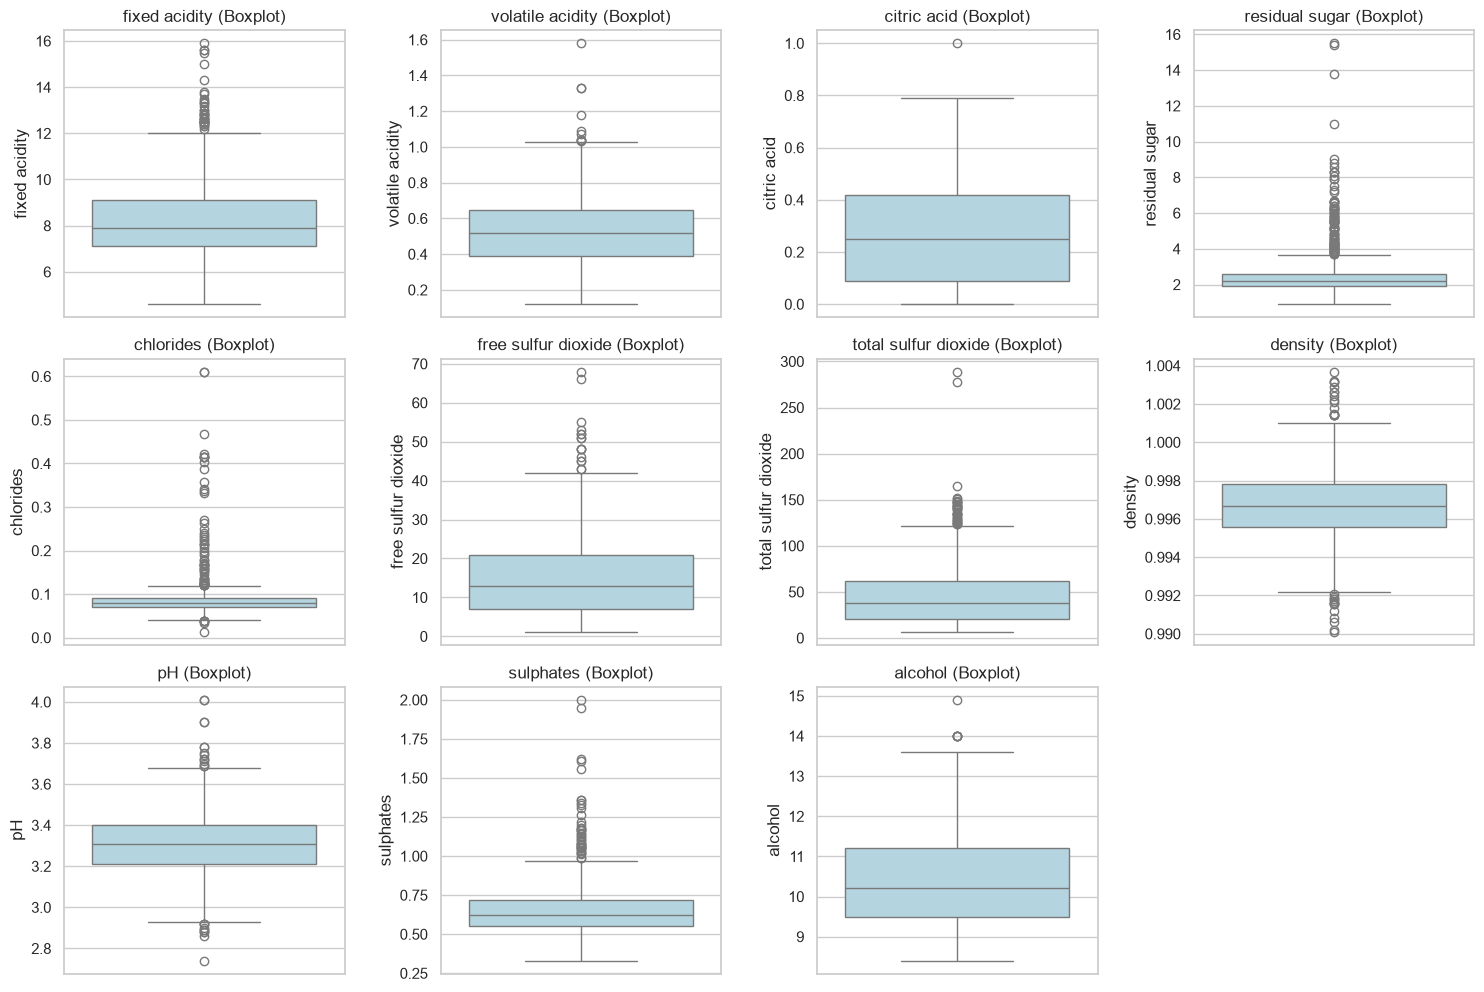

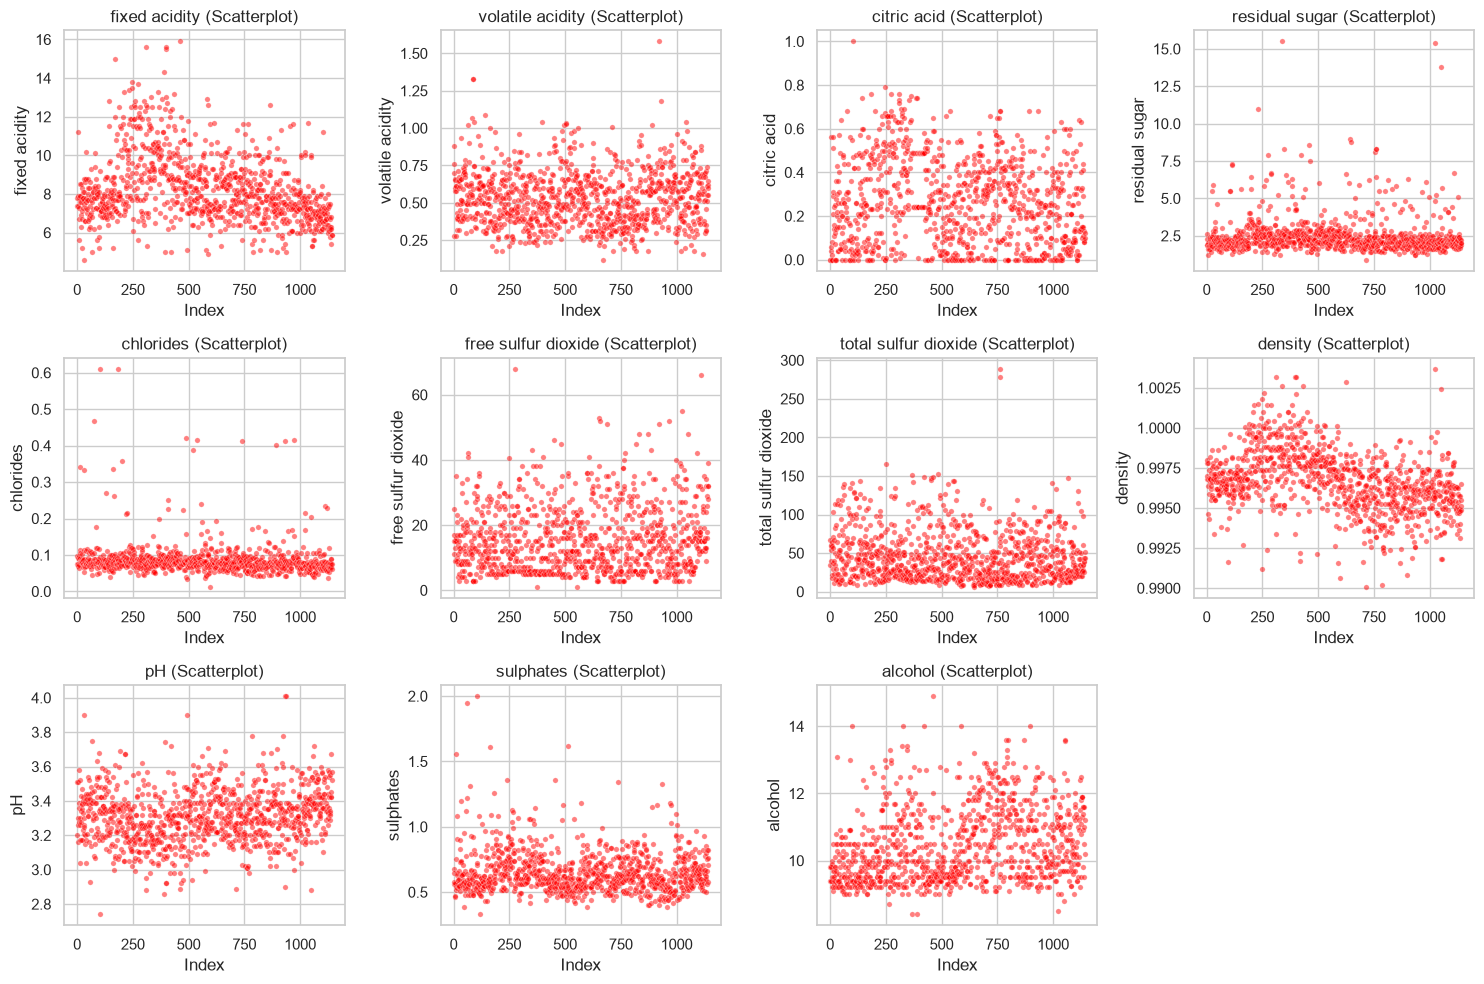

In [6]:
# Periksa Outliers (jika diperlukan), misalnya menggunakan boxplot atau metode statistik lainnya. (Bisa dilakukan eksperimen dengan dan tanpa outlier untuk melihat perbedaan performa model)
fitur = data.drop('quality', axis=1).columns
plt.figure(figsize=(15, 10))
for i, col in enumerate(fitur):
    plt.subplot(3, 4, i+1)
    sns.boxplot(y=data[col], color='lightblue')
    plt.title(f"{col} (Boxplot)")
plt.tight_layout()
plt.show()

plt.figure(figsize=(15, 10))
for i, col in enumerate(fitur):
    plt.subplot(3, 4, i+1)
    sns.scatterplot(x=data.index, y=data[col], color='red', alpha=0.5, s=15)
    plt.title(f"{col} (Scatterplot)")
    plt.xlabel('Index')
    plt.ylabel(col)
plt.tight_layout()
plt.show()

In [7]:
# Scaling data (jika diperlukan), misalnya menggunakan StandardScaler atau MinMaxScaler. (Bisa dilakukan eksperimen dengan dan tanpa scaling untuk melihat perbedaan performa model)
# Perhatikan data leakage saat melakukan scaling. Scaling harus dilakukan setelah membagi data menjadi train dan test set.
X = data.drop('quality', axis=1)
y = data['quality']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("Shape X_train_scaled:", X_train_scaled.shape)
print("Shape X_test_scaled:", X_test_scaled.shape)

Shape X_train_scaled: (814, 11)
Shape X_test_scaled: (204, 11)


# 3. Eksperimen Model KNN


In [8]:
# Split data menjadi train dan test set. (misal 80% train, 20% test)
# Gunakan fungsi train_test_split dari sklearn.model_selection untuk membagi data menjadi train dan test set. Pastikan untuk memisahkan fitur (X) dan label (y) sebelum melakukan split.
# Gunakan stratify=y agar distribusi label pada train dan test set tetap sama dengan distribusi label pada dataset asli.
# Train model KNN menggunakan train set. Gunakan fungsi KNeighborsClassifier dari sklearn.neighbors untuk membuat model KNN. Lakukan eksperimen dengan berbagai nilai k (misal k=1, 3, 5, 7, 9) dan catat performa model pada train set dan test set.
k_values = [1, 3, 5, 7, 9]
distance_metrics = ['euclidean', 'manhattan']

eksperimen_results = []
trained_models = {}

for metric in distance_metrics:
    for k in k_values:
        knn = KNeighborsClassifier(n_neighbors=k, metric=metric)
        knn.fit(X_train_scaled, y_train)

        y_train_pred = knn.predict(X_train_scaled)
        y_test_pred = knn.predict(X_test_scaled)

        acc_train = accuracy_score(y_train, y_train_pred)
        acc_test = accuracy_score(y_test, y_test_pred)
        
        eksperimen_results.append({
            'Metric Jarak': metric,
            'k': k,
            'Akurasi Train': acc_train,
            'Akurasi Test': acc_test
        })
        trained_models[f"{metric}_k{k}"] = y_test_pred

df_eksperimen = pd.DataFrame(eksperimen_results)
display(df_eksperimen.sort_values(by='Akurasi Test', ascending=False))

,Metric Jarak,k,Akurasi Train,Akurasi Test
4,euclidean,9,0.647420,0.578431
3,euclidean,7,0.654791,0.568627
2,euclidean,5,0.678133,0.558824
8,manhattan,7,0.664619,0.553922
9,manhattan,9,0.651106,0.544118
0,euclidean,1,1.000000,0.514706
5,manhattan,1,1.000000,0.514706
1,euclidean,3,0.734644,0.509804
7,manhattan,5,0.687961,0.480392
6,manhattan,3,0.729730,0.470588


# 4. Evaluasi Model


--- Evaluasi Detail untuk Model Terbaik (k=9, Jarak=euclidean) ---
Accuracy  : 0.5784
Precision : 0.5544
Recall    : 0.5784
F1-Score  : 0.5627

Classification Report:
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00         7
           5       0.67      0.66      0.66        87
           6       0.53      0.65      0.58        82
           7       0.47      0.33      0.39        24
           8       0.00      0.00      0.00         3

    accuracy                           0.58       204
   macro avg       0.28      0.27      0.27       204
weighted avg       0.55      0.58      0.56       204



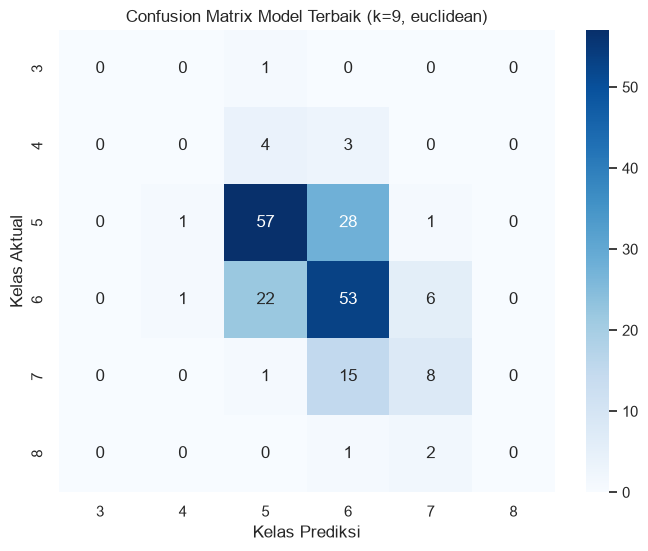

In [10]:
# Tampilkan evaluasi model KNN dengan metriks evaluasi yang sesuai dengan tipe masalah klasifikasi
best_model_info = df_eksperimen.sort_values(by='Akurasi Test', ascending=False).iloc[0]
best_k = best_model_info['k']
best_metric = best_model_info['Metric Jarak']

print(f"--- Evaluasi Detail untuk Model Terbaik (k={best_k}, Jarak={best_metric}) ---")

best_model_key = f"{best_metric}_k{best_k}"
y_pred_best = trained_models[best_model_key]

acc = accuracy_score(y_test, y_pred_best)
prec = precision_score(y_test, y_pred_best, average='weighted', zero_division=0)
rec = recall_score(y_test, y_pred_best, average='weighted', zero_division=0)
f1 = f1_score(y_test, y_pred_best, average='weighted', zero_division=0)

print(f"Accuracy  : {acc:.4f}")
print(f"Precision : {prec:.4f}")
print(f"Recall    : {rec:.4f}")
print(f"F1-Score  : {f1:.4f}\n")
print("Classification Report:")
print(classification_report(y_test, y_pred_best, zero_division=0))

plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(y), yticklabels=np.unique(y))
plt.title(f'Confusion Matrix Model Terbaik (k={best_k}, {best_metric})')
plt.xlabel('Kelas Prediksi')
plt.ylabel('Kelas Aktual')
plt.show()

# 5. Analisis

### 

Berdasarkan eksperimen pemodelan *K-Nearest Neighbors* (KNN) yang dilakukan pada dataset *Wine Quality*, dapat kita ambil beberapa poin penting :

* **Perbandingan Hyperparameter:** Dari hasil pencarian parameter,ternyata metrik jarak *Euclidean* memberikan akurasi yang sedikit lebih baik dibandingkan *Manhattan*. Selain itu, terlihat bahwa nilai $k$ yang lebih besar memberikan generalisasi yang lebih baik pada data *test*. Pada $k=1$, model mengalami *overfitting* yang mana akurasi *Train* mencapai 1.0 atau 100%, tapi akurasi *Test* hanya ~51.4%.
* **Performa Model Terbaik:** Model terbaik didapatkan pada kombinasi parameter **$k=9$ dan metrik jarak *Euclidean***, yang menghasilkan Akurasi *Test* sebesar **57.84%**.
* **Dampak *Imbalanced Data* (Ketimpangan Data):** Evaluasi lanjutan menggunakan *Classification Report* dan *Confusion Matrix* menunjukkan bahwa akurasi 57.84% tersebut "semu" karena sangat didorong oleh kelas mayoritas. Model gagal memprediksi kelas minoritas (kualitas 3, 4, dan 8), dengan nilai *Precision*, *Recall*, dan *F1-Score* sebesar `0.00`. Ini terjadi karena KNN bergantung pada "suara terbanyak". Karena dataset didominasi oleh kelas 5 dan 6, tetangga terdekat dari sebuah data baru kemungkinan besar akan selalu jatuh ke kelas 5 atau 6.
* **Sifat Klasifikasi Ordinal:** Kesalahan tebakan model (*misclassification*) mayoritas terjadi pada kelas-kelas yang berdekatan. Misal, data yang aslinya bernilai 4 diprediksi sebagai 5 dan 6. Ini menunjukkan bahwa batasan fitur kimia antar tingkatan kualitas anggur tersebut sangat tipis.


# 6. Kesimpulan dan Saran

### 
**Kesimpulan:**
Eksperimen ini menyimpulkan bahwa model KNN terbaik untuk memprediksi kualitas anggur pada dataset ini menggunakan jarak *Euclidean* dengan $k=9$. Tapi, model ini belum cukup akurat untuk digunakan di dunia nyata. Meskipun mencapai akurasi tes tertinggi di antara eksperimen lain, model ini sangat bias terhadap kelas mayoritas (kualitas 5 dan 6) akibat kondisi dataset yang sangat tidak seimbang (*highly imbalanced*), sehingga gagal mendeteksi kualitas anggur yang sangat rendah maupun sangat tinggi.

**Saran & Rekomendasi:**
Mungkin ada beberapa saran untuk selanjutnya, yaitu :
1. **Penanganan *Imbalanced Data*:** Menerapkan teknik *resampling* sebelum tahap *training*. Teknik yang disarankan adalah **SMOTE** (*Synthetic Minority Over-sampling Technique*) untuk menambah sampel data buatan pada kelas minoritas (3, 4, 7, 8) agar seimbang dengan kelas 5 dan 6.
2. **Penyederhanaan Kelas (*Binning*):** Mengingat target prediksi berupa tingkatan (*ordinal*), target kualitas bisa direkayasa (*feature engineering*) menjadi kelas yang lebih sederhana, misalnya dikelompokkan menjadi 3 kelas: Kualitas 'Rendah' (3-4), 'Sedang' (5-6), dan 'Tinggi' (7-8). Ini akan mengurangi beban klasifikasi.
3. **Eksperimen Algoritma Alternatif:** Mencoba algoritma *Machine Learning* lain yang lebih tangguh (*robust*) terhadap ketidakseimbangan kelas dibandingkan KNN, seperti *Random Forest*, *Decision Tree*, atau *Gradient Boosting*.